# Tag 08 - Fortgeschrittene
## DBSCAN & Silhouette Coefficient

In [1]:
OUTPUT_SUBDIR = "Fortgeschrittene"
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

In [2]:
from pathlib import Path

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent

DATA_DIR = PROJECT_DIR / "data"
OUT_DIR = PROJECT_DIR / "output" / OUTPUT_SUBDIR
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_DIR:", DATA_DIR)
print("OUT_DIR:", OUT_DIR)

PROJECT_DIR: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\customer-segmentation-rfm-kmeans
DATA_DIR: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\customer-segmentation-rfm-kmeans\data
OUT_DIR: C:\Users\esmae\Documents\Educx Kurs machine lerning\ML_Projekt_Workspace\customer-segmentation-rfm-kmeans\output\Fortgeschrittene


In [3]:
possible_files = [
    "Online Retail.xlsx", "Online_Retail.xlsx", "online_retail.xlsx",
    "Online Retail.csv", "Online_Retail.csv", "online_retail.csv"
]
DATA_PATH = next((DATA_DIR / f for f in possible_files if (DATA_DIR / f).exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(f"Put Online Retail data in {DATA_DIR}. Accepted names: {possible_files}")

if DATA_PATH.suffix.lower() in [".xlsx", ".xls"]:
    retail = pd.read_excel(DATA_PATH)
else:
    retail = pd.read_csv(DATA_PATH, encoding="latin1")

retail.columns = retail.columns.astype(str).str.strip()

retail = retail.rename(columns={
    "Customer ID": "CustomerID",
    "CustomerID": "CustomerID",
    "Invoice": "InvoiceNo",
    "InvoiceNo": "InvoiceNo",
    "Invoice Date": "InvoiceDate",
    "InvoiceDate": "InvoiceDate",
    "Price": "UnitPrice",
    "UnitPrice": "UnitPrice"
})

print("Using file:", DATA_PATH.name)
print("Shape:", retail.shape)
print("Columns:", retail.columns.tolist())
retail.head()


Using file: Online_Retail.csv
Shape: (541909, 8)
Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
required_cols = ["CustomerID", "InvoiceNo", "InvoiceDate", "Quantity", "UnitPrice"]
missing = [c for c in required_cols if c not in retail.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}\nAvailable columns: {list(retail.columns)}")

retail = retail.dropna(subset=["CustomerID", "InvoiceDate", "InvoiceNo", "Quantity", "UnitPrice"]).copy()
retail["InvoiceDate"] = pd.to_datetime(retail["InvoiceDate"], errors="coerce")
retail["Quantity"] = pd.to_numeric(retail["Quantity"], errors="coerce")
retail["UnitPrice"] = pd.to_numeric(retail["UnitPrice"], errors="coerce")
retail = retail.dropna(subset=["InvoiceDate", "Quantity", "UnitPrice"])
retail = retail[(retail["Quantity"] > 0) & (retail["UnitPrice"] > 0)].copy()
retail["TotalPrice"] = retail["Quantity"] * retail["UnitPrice"]
retail["CustomerID"] = retail["CustomerID"].astype(str)
print(retail.shape)
retail.head()


(397884, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [5]:
snapshot_date = retail["InvoiceDate"].max() + pd.Timedelta(days=1)
rfm = retail.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum")
).reset_index()

rfm = rfm[(rfm["Frequency"] > 0) & (rfm["Monetary"] > 0)].copy()
rfm.to_csv(OUT_DIR / "intermediate_rfm_raw.csv", index=False)
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [6]:
features = ["Recency", "Frequency", "Monetary"]
scaler = StandardScaler()
X_rfm = scaler.fit_transform(rfm[features])
X_rfm_df = pd.DataFrame(X_rfm, columns=features)
X_rfm_df.to_csv(OUT_DIR / "intermediate_rfm_scaled.csv", index=False)
X_rfm_df.describe()

,Recency,Frequency,Monetary
count,4.338000e+03,4.338000e+03,4.338000e+03
mean,2.702618e-17,1.801745e-17,1.801745e-17
std,1.000115e+00,1.000115e+00,1.000115e+00
min,-9.153401e-01,-4.250965e-01,-2.281344e-01
25%,-7.453445e-01,-4.250965e-01,-1.943495e-01
50%,-4.153533e-01,-2.951776e-01,-1.535104e-01
75%,4.946227e-01,9.457903e-02,-4.367134e-02
max,2.814561e+00,2.659803e+01,3.094634e+01


In [7]:
dbscan_rows = []
best_dbscan = None
best_dbscan_score = -1

for eps in [0.5, 1.0, 2.0]:
    for ms in [3, 5, 10]:
        labels = DBSCAN(eps=eps, min_samples=ms).fit_predict(X_rfm)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = int((labels == -1).sum())
        score = np.nan
        mask = labels != -1
        if n_clusters >= 2 and mask.sum() > n_clusters:
            score = silhouette_score(X_rfm[mask], labels[mask])
            if score > best_dbscan_score:
                best_dbscan_score = score
                best_dbscan = {"eps": eps, "min_samples": ms, "labels": labels, "silhouette": score}
        dbscan_rows.append({"eps": eps, "min_samples": ms, "n_clusters": n_clusters, "n_noise": n_noise, "silhouette_without_noise": score})

DBSCAN_RESULTS = pd.DataFrame(dbscan_rows)
DBSCAN_RESULTS.to_csv(OUT_DIR / "intermediate_dbscan_grid_results.csv", index=False)
DBSCAN_RESULTS

,eps,min_samples,n_clusters,n_noise,silhouette_without_noise
0,0.5,3,1,50,NaN
1,0.5,5,1,54,NaN
2,0.5,10,2,67,0.666216
3,1.0,3,3,26,0.811000
4,1.0,5,1,33,NaN
5,1.0,10,1,38,NaN
6,2.0,3,1,19,NaN
7,2.0,5,1,22,NaN
8,2.0,10,1,29,NaN


In [8]:
kmeans_rows = []
best_kmeans = None
best_kmeans_score = -1

for k in range(2, 9):
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_rfm)
    score = silhouette_score(X_rfm, labels)
    kmeans_rows.append({"k": k, "silhouette": score})
    if score > best_kmeans_score:
        best_kmeans_score = score
        best_kmeans = {"k": k, "labels": labels, "silhouette": score}

KMEANS_RESULTS = pd.DataFrame(kmeans_rows)
KMEANS_RESULTS.to_csv(OUT_DIR / "intermediate_kmeans_silhouette_results.csv", index=False)
KMEANS_RESULTS

C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Das System kann die angegebene Datei nicht finden
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\esmae\Documents\Educx Kurs machine lerning\aufgabe\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\esmae\.conda\envs\py311\Li

,k,silhouette
0,2,0.895817
1,3,0.594188
2,4,0.616213
3,5,0.616523
4,6,0.596317
5,7,0.516470
6,8,0.517459


In [9]:
comparison = pd.DataFrame([
    {"method": f"K-Means k={best_kmeans['k']}", "silhouette": best_kmeans["silhouette"], "notes": "all points"},
    {"method": f"DBSCAN eps={best_dbscan['eps']} min_samples={best_dbscan['min_samples']}" if best_dbscan else "DBSCAN", "silhouette": best_dbscan["silhouette"] if best_dbscan else np.nan, "notes": "noise excluded" if best_dbscan else "no valid clustering"}
])
comparison.to_csv(OUT_DIR / "intermediate_silhouette_comparison.csv", index=False)
comparison

,method,silhouette,notes
0,K-Means k=2,0.895817,all points
1,DBSCAN eps=1.0 min_samples=3,0.811000,noise excluded


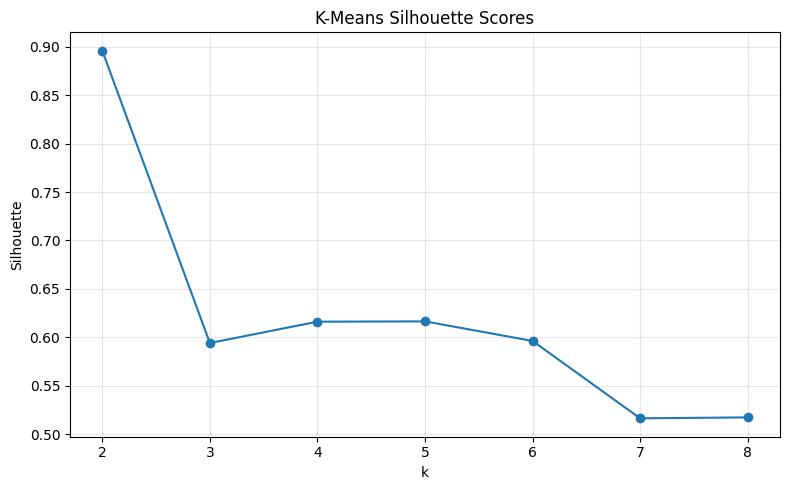

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(KMEANS_RESULTS["k"], KMEANS_RESULTS["silhouette"], marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.title("K-Means Silhouette Scores")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / "intermediate_kmeans_silhouette_curve.png", dpi=160)
plt.show()

if best_dbscan:
    rfm_out = rfm.copy()
    rfm_out["dbscan_label"] = best_dbscan["labels"]
    rfm_out["kmeans_label"] = best_kmeans["labels"]
    rfm_out.to_csv(OUT_DIR / "intermediate_rfm_with_cluster_labels.csv", index=False)